# CKA Analysis

In [10]:
import math
import numpy as np


def centering(K):
    n = K.shape[0]
    unit = np.ones([n, n])
    I = np.eye(n)
    H = I - unit / n

    return np.dot(np.dot(H, K), H)  # HKH are the same with KH, KH is the first centering, H(KH) do the second time, results are the sme with one time centering
    # return np.dot(H, K)  # KH


def rbf(X, sigma=None):
    GX = np.dot(X, X.T)
    KX = np.diag(GX) - GX + (np.diag(GX) - GX).T
    if sigma is None:
        mdist = np.median(KX[KX != 0])
        sigma = math.sqrt(mdist)
    KX *= - 0.5 / (sigma * sigma)
    KX = np.exp(KX)
    return KX


def kernel_HSIC(X, Y, sigma):
    return np.sum(centering(rbf(X, sigma)) * centering(rbf(Y, sigma)))


def linear_HSIC(X, Y):
    L_X = np.dot(X, X.T)
    L_Y = np.dot(Y, Y.T)
    return np.sum(centering(L_X) * centering(L_Y))


def linear_CKA(X, Y):
    hsic = linear_HSIC(X, Y)
    var1 = np.sqrt(linear_HSIC(X, X))
    var2 = np.sqrt(linear_HSIC(Y, Y))

    return hsic / (var1 * var2)


def kernel_CKA(X, Y, sigma=None):
    hsic = kernel_HSIC(X, Y, sigma)
    var1 = np.sqrt(kernel_HSIC(X, X, sigma))
    var2 = np.sqrt(kernel_HSIC(Y, Y, sigma))

    return hsic / (var1 * var2)


if __name__=='__main__':
    X = np.random.randn(100, 64)
    Y = np.random.randn(100, 64)

    print('Linear CKA, between X and Y: {}'.format(linear_CKA(X, Y)))
    print('Linear CKA, between X and X: {}'.format(linear_CKA(X, X)))

    print('RBF Kernel CKA, between X and Y: {}'.format(kernel_CKA(X, Y)))
    print('RBF Kernel CKA, between X and X: {}'.format(kernel_CKA(X, X)))

Linear CKA, between X and Y: 0.3828292437008145
Linear CKA, between X and X: 1.0
RBF Kernel CKA, between X and Y: 0.5152215709737286
RBF Kernel CKA, between X and X: 1.0000000000000002


In [27]:
import os
os.chdir("/home/hice1/stekin6/scratch/rl-vqa")
import torch

from models.multi_encoder import MultiEncoderSharedAutoencoder
from train_multi_encoder import  EmbeddingLoader, collate_fn
from torch.utils.data import Dataset, DataLoader


model_names = ["llava-v1.6-vicuna-7b-hf", "llava-v1.6-vicuna-13b-hf", "Qwen2.5-VL-7B-Instruct", "InternVL2-8B", "deepseek-vl2-tiny"]
dataset_name = "mmmu"
val_dataset = EmbeddingLoader(dataset_name, model_names, split_type="validation")
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

loading embeddings
embeddings are loaded


In [28]:
all_data = []
for batch in val_dataloader:
    all_data.append(batch)
        

In [29]:
concat_data = []
for i in range(len(model_names)):
    concat_data.append(torch.cat([batch[i] for batch in all_data]))

In [30]:
indices_to_remove = torch.tensor(skip_list)
mask = torch.ones(len(concat_data[0]), dtype=torch.bool)
mask[indices_to_remove] = False

In [31]:
mask.shape

torch.Size([900])

In [32]:
for b in concat_data:
    b = b[mask]
    print(b.shape)

torch.Size([805, 1024])
torch.Size([805, 1024])
torch.Size([805, 3584])
torch.Size([805, 1024])
torch.Size([805, 1152])


In [33]:
def calc_cka_matrix(in_data):
    num_models = len(in_data)
    cka_matrix = np.zeros((num_models, num_models))
    for i in range(num_models):
        for j in range(i, num_models):
            X = in_data[i].to(torch.float32).cpu().numpy()
            Y = in_data[j].to(torch.float32).cpu().numpy()
            cka_matrix[i, j] = linear_CKA(X, Y)
            cka_matrix[j, i] = cka_matrix[i, j]
    return cka_matrix
# linear_CKA(batch[0].to(torch.float32).cpu().numpy(), batch[1].to(torch.float32).cpu().numpy())

In [34]:
B = calc_cka_matrix(concat_data)

In [36]:
B

array([[1.        , 0.89717267, 0.63567793, 0.37601186, 0.66379885],
       [0.89717267, 1.        , 0.64311136, 0.3449225 , 0.62086258],
       [0.63567793, 0.64311136, 1.        , 0.49278021, 0.75041153],
       [0.37601186, 0.3449225 , 0.49278021, 1.        , 0.40955029],
       [0.66379885, 0.62086258, 0.75041153, 0.40955029, 1.        ]])

In [37]:
def calc_focal_cka(comb, S):
    avg_cka = 0
    count = 0
    for i, j in itertools.combinations(comb, 2):
        avg_cka += S[i, j]
        count += 1
    avg_cka = avg_cka / count
    return avg_cka


# Load Model predictions

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from data_generator.data_loader import DataCreator


for i in range(len(model_names)):
    data_name = f"results/inference/okvqa/validation/{model_names[i]}_output.csv"
    data_df = pd.read_csv(data_name, index_col=0)
    # print(data_df.head())


ds_creator = DataCreator("mmmu")
i = 0
skip_list = []
for dataset_obj in ds_creator.get("validation"):
    for example in dataset_obj:
        images = [example[f"image_{i}"] for i in range(1, 8) if example[f"image_{i}"] is not None]
        if len(images) != 1 or example.get("question_type", "multiple-choice") == "open":
            skip_list.append(i)
            print(i)
        i += 1
        
        

Loading MMMU dataset: 100%|██████████| 30/30 [00:40<00:00,  1.34s/it, status=Loading Sociology...]                          


55
73
83
120
123
130
135
146
159
163
189
203
208
213
219
221
222
227
228
229
232
234
235
238
239
252
278
280
292
295
297
345
373
379
384
391
393
394
395
400
401
405
410
413
414
415
416
418
419
457
459
466
469
472
473
474
479
483
493
495
501
524
527
544
572
586
589
590
592
594
610
639
644
657
662
674
678
708
720
735
740
742
748
752
753
767
768
771
775
800
810
826
829
830
839


In [38]:
from data_generator.inference_loader import load_infer_prob_data
from ens_pruning.ens_methods import voting

dataset_name = "mmmu" # okvqa
data = load_infer_prob_data(model_names, dataset_name, "validation")
label = data[:, -1]

model_probs = np.split(data[:, :-1], len(model_names), axis=1)
model_preds = []
for i in range(len(model_names)):
    print(np.mean(model_probs[i].argmax(1) == label))
    model_preds.append(model_probs[i].argmax(1))

model_preds = np.array(model_preds)
voting_ens = voting(model_preds.T, "plurality")

classifications = (model_preds == label).sum(axis=0)

0.3627329192546584
0.36770186335403726
0.515527950310559
0.5130434782608696
0.39751552795031053


In [ ]:
data

(805, 37)

In [39]:
import os
import re
import itertools
import numpy as np
import pandas as pd


infer_dir = "results/inference"

task_name = "mmmu"
ds_split = "validation"


# model_names = ["llava-v1.6-vicuna-7b-hf", "llava-v1.6-vicuna-13b-hf",
#                "Qwen2.5-VL-7B-Instruct", "InternVL2-8B",
#                "deepseek-vl2-tiny", "deepseek-vl2-small"]

model_names = ["llava-v1.6-vicuna-7b-hf", "llava-v1.6-vicuna-13b-hf", "Qwen2.5-VL-7B-Instruct", "InternVL2-8B", "deepseek-vl2-tiny"]


def extract_letter(text):
    match = re.search(r"\((\w)\)", text)
    return match.group(1) if match else ""

error_list, pred_list = [], []
for mn in model_names:
    data_path = os.path.join(infer_dir, task_name, ds_split, f"{mn}_output.csv")
    data_df = pd.read_csv(data_path)

    arr_path = os.path.join(infer_dir, task_name, ds_split, f"{mn}_prob.npy")
    prob_arr = np.load(arr_path)

    start_chr = 'A'
    choices = []
    for i in range(prob_arr.shape[1]):
        choices.append(start_chr)
        start_chr = chr(ord(start_chr) + 1)

    prob_pred = []
    for i in np.argmax(prob_arr, axis=1):
        prob_pred.append(choices[i])
    prob_pred = np.array(prob_pred, dtype=str)

    generated_outputs = data_df["generated_outputs"].values

    extracted_outputs = []
    for output in generated_outputs:
        pred_txt = str(output)[:10].strip()
        if "\n" in pred_txt:
            pred_txt = pred_txt.split("\n")[1]
        if "(" in pred_txt or ")" in pred_txt:
            pred_txt = extract_letter(pred_txt)
        extracted_outputs.append(pred_txt[:1].upper())
    extracted_outputs = np.array(extracted_outputs)

    labels = data_df["answer"].values.astype(str) 
    if task_name == "mmmu_pro" and "llava" not in mn:
        extracted_outputs = np.delete(extracted_outputs, (1017), axis=0)
        prob_pred = np.delete(prob_pred, (1017), axis=0)
        labels = np.delete(labels, (1017), axis=0)
        prob_arr = np.delete(prob_arr, (1017), axis=0)

    errors = labels == extracted_outputs.astype(str)
    error_list.append(errors.astype(int))
    acc = np.mean(errors)
    
    print(prob_arr.shape)
    print(mn, acc, np.mean(labels.astype(str) == prob_pred))

    label_idx = []
    for i in range(len(labels)):
        label_idx.append(choices.index(labels[i]))
    pred_list.append(np.argmax(prob_arr, 1))


(805, 9)
llava-v1.6-vicuna-7b-hf 0.3590062111801242 0.3627329192546584
(805, 9)
llava-v1.6-vicuna-13b-hf 0.3701863354037267 0.36770186335403726
(805, 9)
Qwen2.5-VL-7B-Instruct 0.5105590062111801 0.515527950310559
(805, 9)
InternVL2-8B 0.5142857142857142 0.5130434782608696
(805, 9)
deepseek-vl2-tiny 0.3838509316770186 0.39751552795031053


In [41]:

from ens_pruning.ens_metrics import calc_div_acc

hist_data = {
    "error_arr": np.array(error_list).T,
    "pred_arr": np.array(pred_list).T,
    "label_arr": np.array(label_idx).astype(int)
}

calc_div_acc(np.ones((len(model_names),), dtype=int), hist_data)


(0.23358518845339954, 0.484472049689441, 0.24501180412763687)

In [17]:
np.ones((len(model_names),))

array([1., 1., 1., 1.])

In [42]:

num_models = len(model_names)
scores = []
comb_list = []
ens_sizes = np.arange(2, num_models + 1)
for j, ens_size in enumerate(ens_sizes):
    print(ens_size)
    combinations = list(itertools.combinations(range(num_models), ens_size))
    for comb in combinations:
        comb_idx = np.zeros(num_models, dtype=int)
        comb_idx[list(comb)] = 1
        scores.append(calc_div_acc(comb_idx, hist_data)) # returns focal_div, acc_score, fleiss_kappa
        comb_list.append(comb_idx)
scores = np.array(scores)


2
3
4
5


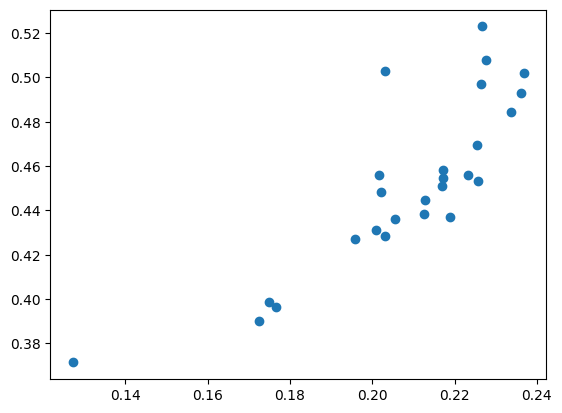

In [43]:
fig, ax = plt.subplots()

ax.scatter(scores[:, 0], scores[:, 1])


In [44]:
ens_sizes = np.arange(2, num_models + 1)
combs, cka_scores = [],[]
for j, ens_size in enumerate(ens_sizes):
    print(ens_size)
    combinations = list(itertools.combinations(range(num_models), ens_size))
    for comb in combinations:
        focal_cka_score = calc_focal_cka(comb, B)
        combs.append(comb)
        cka_scores.append(focal_cka_score)

2
3
4
5


In [45]:
cka_scores

[0.8971726719587675,
 0.6356779332662813,
 0.3760118552636751,
 0.6637988480922445,
 0.6431113590481911,
 0.34492249586353907,
 0.6208625848617352,
 0.49278020548033435,
 0.7504115259082187,
 0.40955028850303643,
 0.7253206547577467,
 0.5393690076953273,
 0.7272780349709157,
 0.5014899980034303,
 0.6832961024222483,
 0.48312033061965204,
 0.49360468679735486,
 0.6714618232727151,
 0.4584451230761036,
 0.5509140066305298,
 0.5649460868134647,
 0.7018391538559063,
 0.5520531240904997,
 0.5547051094189651,
 0.5436064099441758,
 0.5834299768246023]

In [22]:
B

array([[1.        , 0.63567793, 0.37601186, 0.66379885],
       [0.63567793, 1.        , 0.49278021, 0.75041153],
       [0.37601186, 0.49278021, 1.        , 0.40955029],
       [0.66379885, 0.75041153, 0.40955029, 1.        ]])

In [46]:
acc_scores = scores[:, 1]

In [ ]:

for i in range(len(scores)):
    print(combs[i], acc_scores[i], cka_scores[i])

(0, 1) 0.37142857142857144 0.8971726719587675
(0, 2) 0.45590062111801244 0.6356779332662813
(0, 3) 0.44472049689440996 0.3760118552636751
(0, 4) 0.39006211180124223 0.6637988480922445
(1, 2) 0.43105590062111804 0.6431113590481911
(1, 3) 0.4484472049689441 0.34492249586353907
(1, 4) 0.39627329192546584 0.6208625848617352
(2, 3) 0.5031055900621118 0.49278020548033435
(2, 4) 0.4360248447204969 0.7504115259082187
(3, 4) 0.4509316770186335 0.40955028850303643
(0, 1, 2) 0.42732919254658386 0.7253206547577467
(0, 1, 3) 0.42857142857142855 0.5393690076953273
(0, 1, 4) 0.3987577639751553 0.7272780349709157
(0, 2, 3) 0.5080745341614907 0.5014899980034303
(0, 2, 4) 0.4546583850931677 0.6832961024222483
(0, 3, 4) 0.453416149068323 0.48312033061965204
(1, 2, 3) 0.4968944099378882 0.49360468679735486
(1, 2, 4) 0.4583850931677019 0.6714618232727151
(1, 3, 4) 0.45590062111801244 0.4584451230761036
(2, 3, 4) 0.5229813664596273 0.5509140066305298
(0, 1, 2, 3) 0.46956521739130436 0.5649460868134647
(0, 1

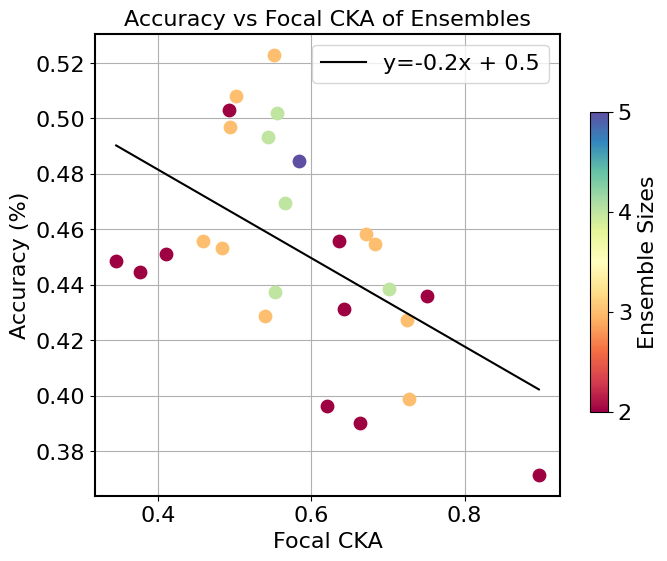

In [133]:

from matplotlib import cm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

plt.rcParams.update({
        'font.size': 14,              # General font size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 16,         # Axis label font size
        'xtick.labelsize': 16,        # X-axis tick font size
        'ytick.labelsize': 16,        # Y-axis tick font size
        'legend.fontsize': 16         # Legend font size
        
    })


fig, ax = plt.subplots(figsize=(6, 6))

# combs = np.array([len(j) for j in combs])
normalize = mcolors.Normalize(vmin=2, vmax=ens_sizes[-1])
colormap = cm.Spectral

for i, ens_size in enumerate(ens_sizes):
    idx = combs == ens_size
    ax.scatter(np.array(cka_scores)[idx], np.array(acc_scores)[idx], s=80, color=np.array(colormap(normalize(ens_size))), zorder=2)

x, y = np.array(cka_scores), np.array(acc_scores)
a, b = np.polyfit(x, y, 1)
x_axis = np.linspace(min(cka_scores), max(cka_scores), 100)
ax.plot(x_axis, x_axis * a + b, color="k", label=f"y={a:.1f}x + {b:.1f}", zorder=3)

scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
scalarmappaple.set_array(range(2, ens_sizes[-1]))
cax = fig.add_axes([0.95, 0.25, 0.03, 0.5])  # [left, bottom, width, height]
fig.colorbar(scalarmappaple, cax=cax, ticks=np.arange(2, ens_sizes[-1]+1), orientation='vertical', label='Ensemble Sizes', shrink=2, aspect=30)
ax.set_xlabel("Focal CKA")
ax.set_ylabel("Accuracy (%)")
ax.grid(zorder=0)
ax.legend()
# cbar.ax.tick_params(labelsize=14)

ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.set_title("Accuracy vs Focal CKA of Ensembles")
plt.savefig("cka_scatter.png", dpi=150, bbox_inches="tight")

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(np.array(cka_scores).reshape(1, -1), np.array(acc_scores).reshape(1, -1))
x_axis = np.linspace(min(cka_scores), max(cka_scores), 100)
y_pred = model.predict(np.array(cka_scores).reshape(1, -1))

In [114]:
x_axis * a + b

array([0.49024294, 0.48935369, 0.48846443, 0.48757518, 0.48668593,
       0.48579668, 0.48490742, 0.48401817, 0.48312892, 0.48223967,
       0.48135041, 0.48046116, 0.47957191, 0.47868266, 0.47779341,
       0.47690415, 0.4760149 , 0.47512565, 0.4742364 , 0.47334714,
       0.47245789, 0.47156864, 0.47067939, 0.46979013, 0.46890088,
       0.46801163, 0.46712238, 0.46623312, 0.46534387, 0.46445462,
       0.46356537, 0.46267612, 0.46178686, 0.46089761, 0.46000836,
       0.45911911, 0.45822985, 0.4573406 , 0.45645135, 0.4555621 ,
       0.45467284, 0.45378359, 0.45289434, 0.45200509, 0.45111584,
       0.45022658, 0.44933733, 0.44844808, 0.44755883, 0.44666957,
       0.44578032, 0.44489107, 0.44400182, 0.44311256, 0.44222331,
       0.44133406, 0.44044481, 0.43955555, 0.4386663 , 0.43777705,
       0.4368878 , 0.43599855, 0.43510929, 0.43422004, 0.43333079,
       0.43244154, 0.43155228, 0.43066303, 0.42977378, 0.42888453,
       0.42799527, 0.42710602, 0.42621677, 0.42532752, 0.42443